In [2]:
%pip install ipython ipykernel numpy matplotlib ipympl ipywidgets

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


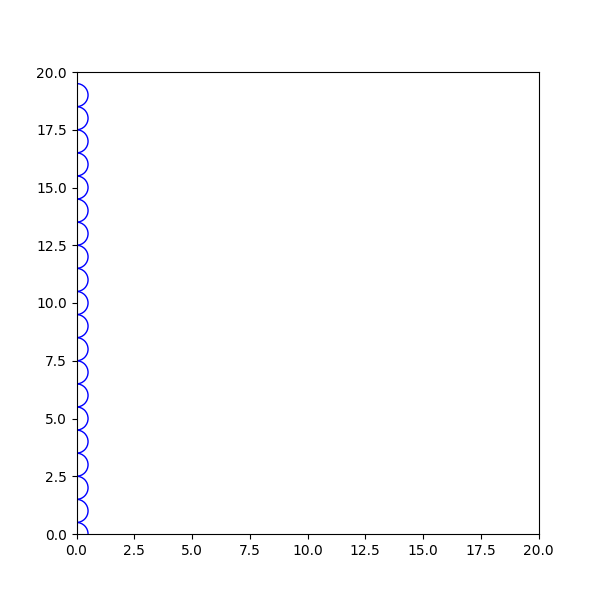

In [15]:
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import glob
from matplotlib.patches import Circle


files = glob.glob("confs/c*")
filenames = sorted(files, key=lambda x: int(x.split("confs\\conf")[1])) # I changed /conf to confs\\conf

fig, ax = plt.subplots(figsize=(6,6))
ax.set(xlim=(0, 20), ylim=(0, 20), aspect='equal')

# List to hold the circle patches (assume number of circles remains constant)
circles = []

# Initialize the first frame
data = np.loadtxt(filenames[0], skiprows=2, usecols=[1,2,3])
for x, y, r in data:
    circle = Circle((x, y), r, edgecolor='b', facecolor='none')
    circles.append(circle)
    ax.add_patch(circle)

def update(frame):
    # Load new data for the frame
    data = np.loadtxt(filenames[frame], skiprows=2, usecols=[1,2,3])
    for patch, (x, y, r) in zip(circles, data):
        # Update circle position and radius
        patch.center = (x, y)
        patch.set_radius(r)
    
    ax.set_title(f'Disk Simulation - Frame {frame}', fontsize=16)
    return circles

ani = FuncAnimation(fig, update, frames=len(filenames), blit=True)
plt.show()